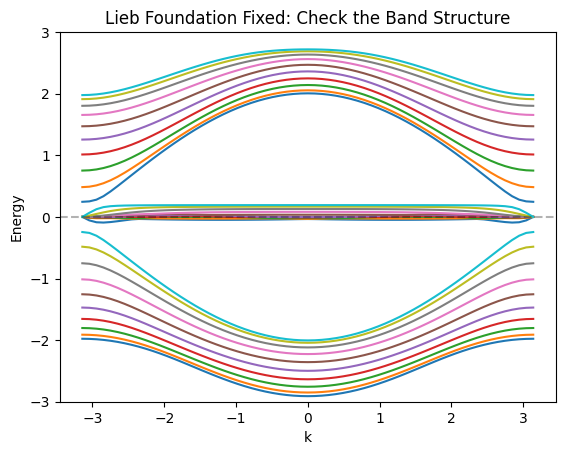

In [2]:
import kwant
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义晶格
lat = kwant.lattice.general([(1, 0), (0, 1)],
                            [(0, 0), (0.5, 0), (0, 0.5)], # A, B, C
                            name=['A', 'B', 'C'])
a, b, c = lat.sublattices

def make_foundation(W=10, f=1.0, g=0.05):
    syst = kwant.Builder(kwant.TranslationalSymmetry([1, 0]))
    
    # --- 修正后的 Onsite 设置 ---
    # 分别给三个子格的格点赋值
    syst[(a(0, j) for j in range(W))] = 0
    syst[(b(0, j) for j in range(W))] = 0
    syst[(c(0, j) for j in range(W))] = 0
    
    # --- 跳跃项 (Hopping) ---
    # 最近邻 f
    syst[kwant.builder.HoppingKind((0, 0), a, b)] = -f
    syst[kwant.builder.HoppingKind((0, 0), a, c)] = -f
    syst[kwant.builder.HoppingKind((-1, 0), a, b)] = -f # 跨原胞 x 方向
    syst[kwant.builder.HoppingKind((0, -1), a, c)] = -f # 跨原胞 y 方向
    
    # 次近邻 g (B-C)
    syst[kwant.builder.HoppingKind((0, 0), b, c)] = -g
    syst[kwant.builder.HoppingKind((-1, 1), b, c)] = -g
    
    return syst

# 运行绘图
foundation = make_foundation(W=10, g=0.1).finalized()
kwant.plotter.bands(foundation, show=False)
plt.ylim(-3, 3)
plt.axhline(0, color='k', linestyle='--', alpha=0.3) # 画一条零能参考线
plt.title("Lieb Foundation Fixed: Check the Band Structure")
plt.show()